In [1]:
library(plyr)
library(dplyr)
library(tidyr)
library(lme4)
library(lmerTest)
library(interactions)
library(ggplot2)
library(emmeans)
library(rempsyc)
library(patchwork)


Attaching package: 'dplyr'


The following objects are masked from 'package:plyr':

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Suggested APA citation: Th<U+00E9>riault, R. (2023). rempsyc: Convenience functions for psychology. 
Journal of Open Source Software, 8(87), 5466. https://doi.org/10.21105/joss.05466



# TF measures predicted by acc * soc * age

## Load data

In [6]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/", analysis_path)

id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'power_early',
    'ITPS_early',
    'ICPS_early_DLPFC_collapsed',
    'ICPS_early_MOTOR_collapsed',
    'ICPS_early_OCC_collapsed',
    'bfne_b_scrdTotal_s1_r1_e1'
)

tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))

tf_data$soc <- as.factor(tf_data$soc)
tf_data$sub <- as.factor(tf_data$sub)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))


# outcome <- "Reaction"
# predictors <- "acc * age_m * soc + sex + dp_inperson + (1 | sub)"

# # Create the string formula
# full_formula_string <- paste(outcome, "~", predictors)
# formula <- as.formula(full_formula_string)
# Convert and run
# model <- lmer(as.formula(full_formula_string), data = sleepstudy)

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_01_02_2026_18_50_11.csv"


## Power

In [20]:
label <- "power_bfne"
model <- lmer(power_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: power_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1606.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6783 -0.5215 -0.0356  0.5385  3.7810 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1455   0.3815  
 Residual             0.2635   0.5133  
Number of obs: 843, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                1.063e-02  4.481e-02  2.227e+02
acc1                                      -7.286e-01  1.775e-02  6.084e+02
age_m                                      1.663e-01  3.083e-02  2.237e+02
soc1                                       1.449e-02  1.807e-02  6.396e+02
bfne_b_scrdTotal_s1_r1_e1                  7.779e-02  3.225e-02  2.238e+02
sex1    

Computing profile confidence intervals ...



In [9]:
label <- "power_bfne"
model <- lmer(power_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
# lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: power_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1606.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6783 -0.5215 -0.0356  0.5385  3.7810 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1455   0.3815  
 Residual             0.2635   0.5133  
Number of obs: 843, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                1.063e-02  4.481e-02  2.227e+02
acc1                                      -7.286e-01  1.775e-02  6.084e+02
age_m                                      1.663e-01  3.083e-02  2.237e+02
soc1                                       1.449e-02  1.807e-02  6.396e+02
bfne_b_scrdTotal_s1_r1_e1                  7.779e-02  3.225e-02  2.238e+02
sex1    

x Detected factor predictor.
i Plotting with cat_plot() instead.
i See `?interactions::cat_plot()` for full details on how to specify models
  with categorical predictors.
i If you experience errors or unexpected results, try using cat_plot()
  directly.


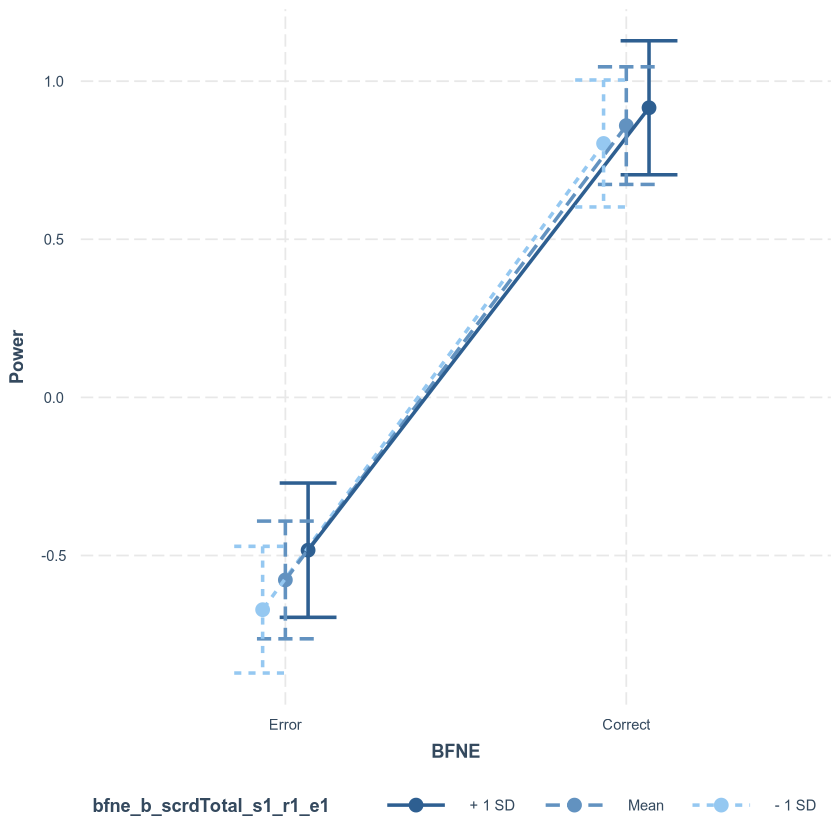

In [25]:
interact_plot(model,
              pred = "acc",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              interval = 1,
              dodge.width = 0.2,
              y.label = "Power",
              x.label = "BFNE",
             ) + theme(legend.position = "bottom")

## ITPS

In [23]:
label <- "ITPS_bfne"
model <- lmer(ITPS_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: ITPS_early ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 2342

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6116 -0.5633 -0.0873  0.4877  3.7298 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2224   0.4716  
 Residual             0.7141   0.8450  
Number of obs: 839, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.013563   0.062231 217.675873
acc1                                       -0.169043   0.029282 602.600666
age_m                                       0.148874   0.042817 218.085859
soc1                                        0.007083   0.029686 640.981915
bfne_b_scrdTotal_s1_r1_e1                   0.020661   0.044726 217.139993
sex1       

Computing profile confidence intervals ...



x Detected factor predictor.
i Plotting with cat_plot() instead.
i See `?interactions::cat_plot()` for full details on how to specify models
  with categorical predictors.
i If you experience errors or unexpected results, try using cat_plot()
  directly.


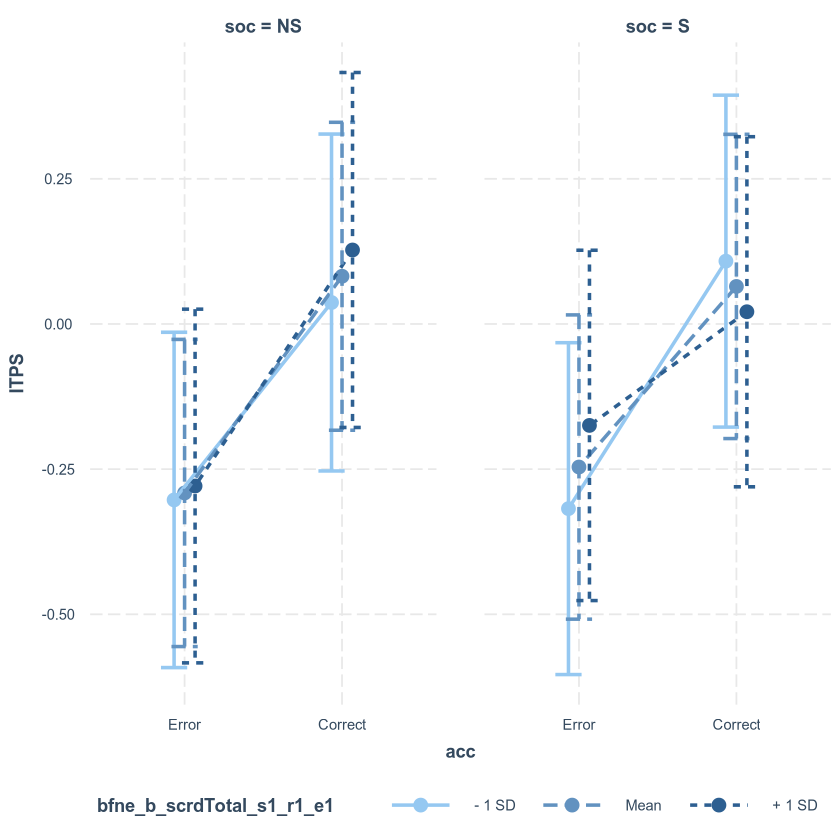

In [5]:
interact_plot(model,
              pred = "acc",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "ITPS",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

In [24]:
# 1. Define the variables for clarity
# Replace "Level_A" and "Level_B" with your actual acc1 factor levels (e.g., 0 and 1)
# If acc1 is numeric, choose specific values like mean +/- SD
my_labels <- c("Low age", "Mean age", "High age")
# --- Plot for Acc Level 1 ---
p1 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Error"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE            # Optional: show raw data
) +
  ggtitle("Error") +
  theme_minimal()

# --- Plot for Acc Level 2 ---
p2 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Correct"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine them ---
# This creates a side-by-side comparison
# p1 + p2

combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") # Optional: merges legends to save even more space

# Save with explicit width (in inches)
ggsave(sprintf("wide_interaction_plot_%s.png", label), combined_plot, width = 16, height = 6, dpi = 300)

## MFC-DLPFC ICPS

In [25]:
label <- "ICPS_DLPFC_bfne"
model <- lmer(ICPS_early_DLPFC_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
ICPS_early_DLPFC_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 2138.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9492 -0.5281 -0.0585  0.4307  4.0191 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1770   0.4207  
 Residual             0.5696   0.7547  
Number of obs: 832, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.028984   0.055889 222.614479
acc1                                       -0.448547   0.026269 599.014887
age_m                                       0.203251   0.038386 221.332715
soc1                                       -0.014295   0.026626 636.306183
bfne_b_scrdTotal_s1_r1_e1                   0.053073   0.039971 217

Computing profile confidence intervals ...



In [26]:
# 1. Define the variables for clarity
# Replace "Level_A" and "Level_B" with your actual acc1 factor levels (e.g., 0 and 1)
# If acc1 is numeric, choose specific values like mean +/- SD
my_labels <- c("Low age", "Mean age", "High age")
# --- Plot for Acc Level 1 ---
p1 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Error"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE            # Optional: show raw data
) +
  ggtitle("Error") +
  theme_minimal()

# --- Plot for Acc Level 2 ---
p2 <- interact_plot(
  model,
  pred = bfne_b_scrdTotal_s1_r1_e1,
  modx = soc,
  mod2 = age_m,
    mod2.labels = my_labels,
  at = list(acc = "Correct"),  # <--- ISOLATE ACC LEVEL HERE
  # plot.points = TRUE
) +
  ggtitle("Correct") +
  theme_minimal()

# --- Combine them ---
# This creates a side-by-side comparison
# p1 + p2

combined_plot <- p1 + p2 + 
  plot_layout(guides = "collect") # Optional: merges legends to save even more space

# Save with explicit width (in inches)
ggsave(sprintf("wide_interaction_plot_%s.png", label), combined_plot, width = 16, height = 6, dpi = 300)

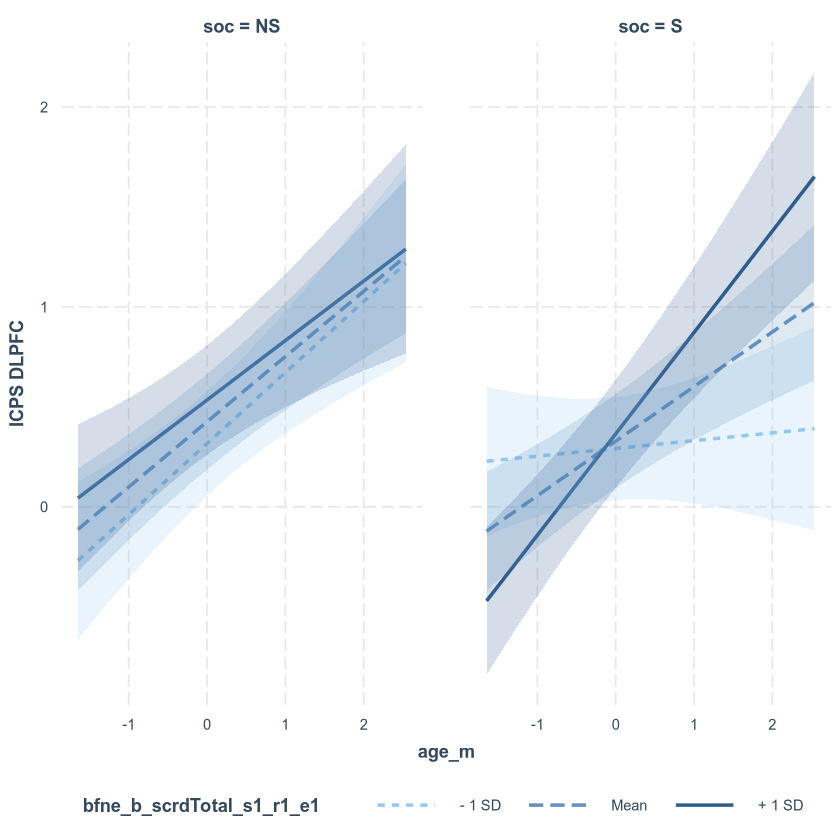

In [39]:
interact_plot(model,
              pred = "age_m",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "ICPS DLPFC",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

## MFC-MOTOR ICPS

In [40]:
label <- "ICPS_MOTOR_bfne"
model <- lmer(ICPS_early_MOTOR_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
ICPS_early_MOTOR_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1992.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6423 -0.5127 -0.0301  0.4650  3.8457 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1554   0.3942  
 Residual             0.4672   0.6835  
Number of obs: 835, groups:  sub, 229

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.030554   0.051262 212.872531
acc1                                       -0.569765   0.023775 596.398182
age_m                                       0.186203   0.035337 213.441412
soc1                                        0.009785   0.024099 632.468670
bfne_b_scrdTotal_s1_r1_e1                   0.049470   0.036937 212

Computing profile confidence intervals ...



## MFC-OCC ICPS

In [19]:
label <- "ICPS_OCC_bfne"
model <- lmer(ICPS_early_OCC_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
ICPS_early_OCC_collapsed ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 2210

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7165 -0.5606  0.0095  0.4960  4.0454 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2234   0.4726  
 Residual             0.6175   0.7858  
Number of obs: 827, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                 0.017564   0.060355 214.397406
acc1                                       -0.393296   0.027504 594.240954
age_m                                       0.058412   0.041736 218.168948
soc1                                        0.005247   0.027893 628.609087
bfne_b_scrdTotal_s1_r1_e1                   0.041285   0.043694 218.996

Computing profile confidence intervals ...



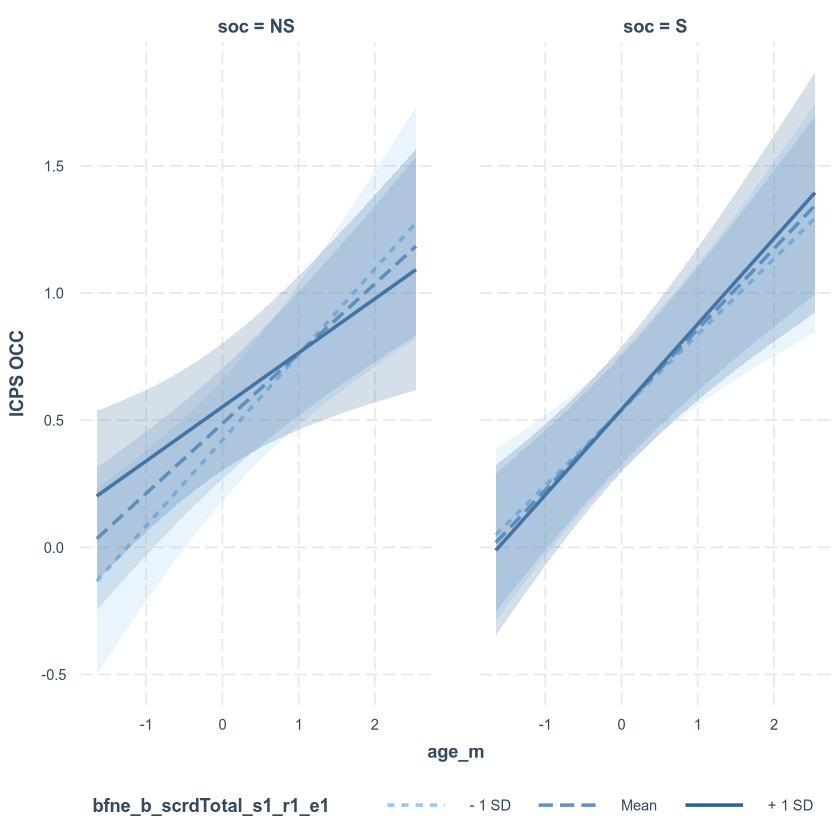

In [42]:
interact_plot(model,
              pred = "age_m",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "ICPS OCC",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

# DDM measures predicted by ICPS

## Load data

In [11]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/", analysis_path)

# it doesnt matter 0 or 1 because the models below use difference scores; because of that we need to get rid of duplicates (diff scores are the same for acc=0 and acc=1)
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'reversed_ratio_diff',
    'a_diff',
    'p_diff',
    'ter_diff',
    'ICPS_early_DLPFC_diff_collapsed',
    'ICPS_early_MOTOR_diff_collapsed',
    'ICPS_early_OCC_diff_collapsed',
    'bfne_b_scrdTotal_s1_r1_e1'
    
)
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))
tf_data <- subset(tf_data, tf_data$acc == 1)

tf_data$sub <- as.factor(tf_data$sub)
tf_data$soc <- as.factor(tf_data$soc)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))

# contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_17_01_2026_19_46_00.csv"


## sda/rd (attentional ratio)

In [10]:
label <- "ratio_reversed"
plot_label <- bquote(paste('Attentional Control', 'sd'['a'], '/r'['d'], '(Post-error - Post-correct)'))
model <- lmer(reversed_ratio_diff ~ ICPS_early_OCC_diff_collapsed * age_m  * soc* bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_DLPFC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 14 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: reversed_ratio_diff ~ ICPS_early_OCC_diff_collapsed * age_m *  
    soc + ICPS_early_DLPFC_diff_collapsed * age_m * soc + sex +  
    dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1034

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.38629 -0.63160  0.05079  0.58236  2.54333 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1343   0.3665  
 Residual             0.8772   0.9366  
Number of obs: 350, groups:  sub, 209

Fixed effects:
                                             Estimate Std. Error         df
(Intercept)                                 -0.036284   0.082481 197.208176
ICPS_early_OCC_diff_collapsed                0.156533   0.059939 317.098200
age_m                                        0.008302   0.058737 181.065772
soc1                                        -0.051132   0.051693 172.715766
ICPS_early

Computing profile confidence intervals ...



In [12]:
label <- "ratio_reversed_motor"
plot_label <- bquote(paste('Attentional Control', 'sd'['a'], '/r'['d'], '(Post-error - Post-correct)'))
model <- lmer(reversed_ratio_diff ~ ICPS_early_MOTOR_diff_collapsed * age_m  * soc* bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: reversed_ratio_diff ~ ICPS_early_MOTOR_diff_collapsed * age_m *  
    soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 |      sub)
   Data: tf_data

REML criterion at convergence: 1074.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3376 -0.5924  0.0017  0.5824  2.5699 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1604   0.4006  
 Residual             0.8537   0.9240  
Number of obs: 360, groups:  sub, 211

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.082891
ICPS_early_MOTOR_diff_collapsed                                        0.048019
age_m                                                                 -0.030607
soc1                                                                  -0.062696
bfne_b_scrdTotal_

Computing profile confidence intervals ...



## a (boundary separation)

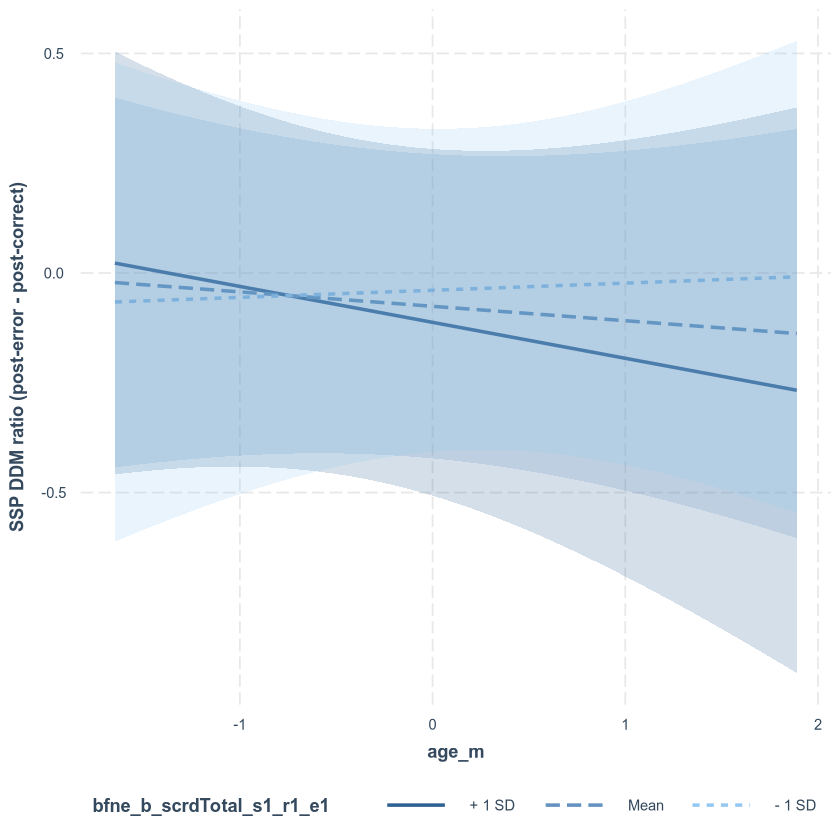

In [14]:
interact_plot(model,
              pred = "age_m",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              interval = 1,
              dodge.width = 0.2,
              y.label = "SSP DDM ratio (post-error - post-correct)",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

In [16]:
label <- "boundary_separation_bfne"
plot_label <- "boundary separation (Error - Correct)"
model <- lmer(a_diff ~ ICPS_early_OCC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_DLPFC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 26 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
a_diff ~ ICPS_early_OCC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_DLPFC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1021.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.48765 -0.64956 -0.05864  0.69163  2.79639 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.01546  0.1243  
 Residual             0.92985  0.9643  
Number of obs: 341, groups:  sub, 204

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.010833
ICPS_early_OCC_diff_collapsed                                          0.119972
age_m                                                                  0.085239
soc1                    

Computing profile confidence intervals ...



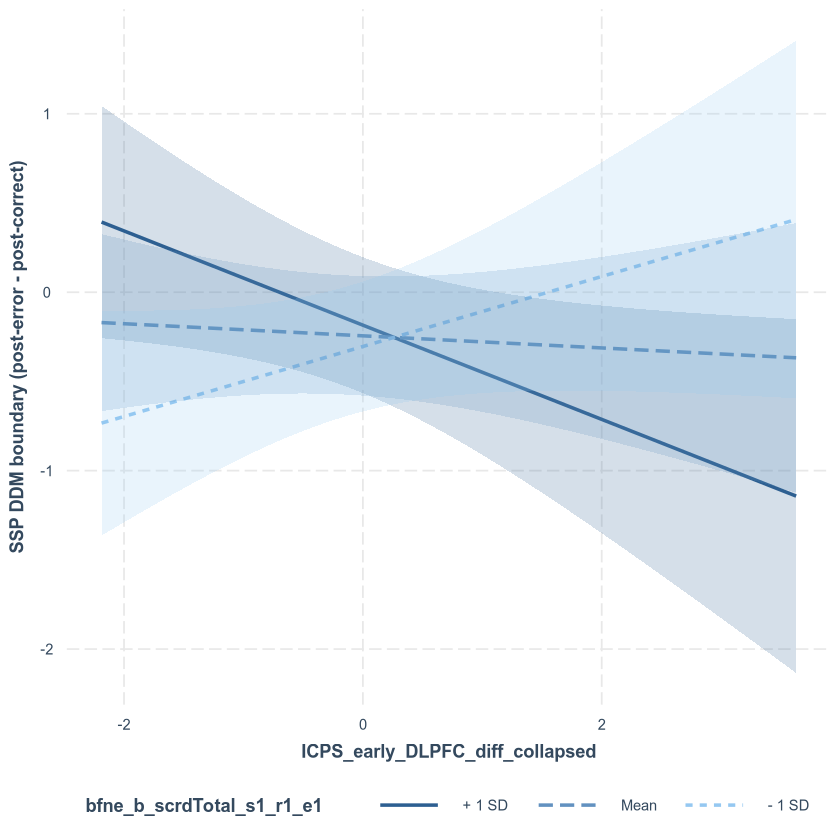

In [22]:
interact_plot(model,
              pred = "ICPS_early_DLPFC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              interval = 1,
              dodge.width = 0.2,
              y.label = "SSP DDM boundary (post-error - post-correct)",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

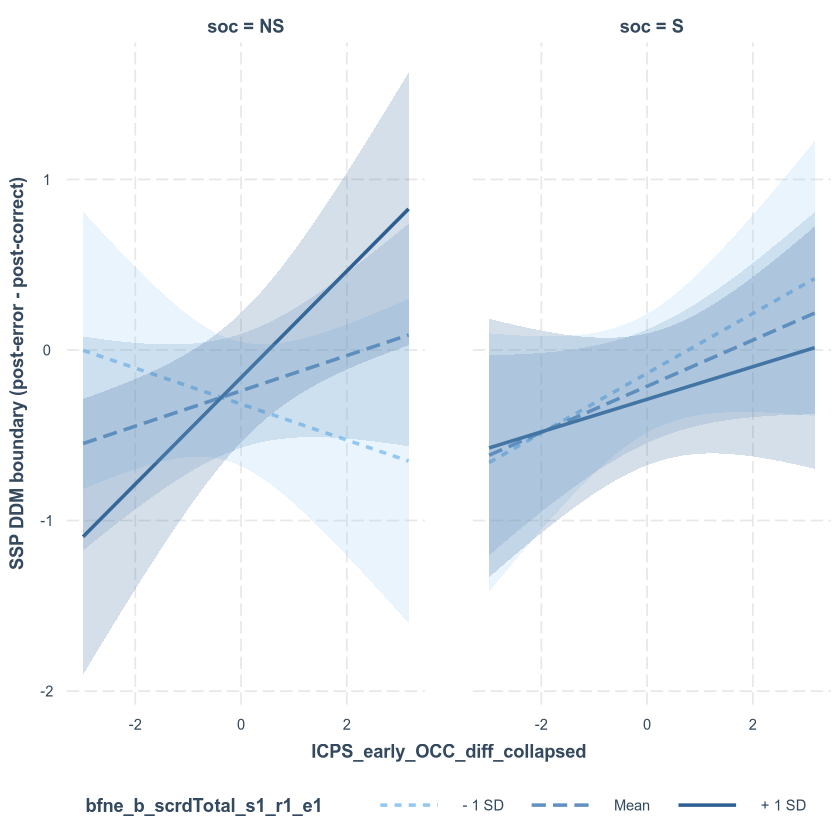

In [23]:
interact_plot(model,
              pred = "ICPS_early_OCC_diff_collapsed",
              modx="bfne_b_scrdTotal_s1_r1_e1",
              mod2="soc",
              interval = 1,
              dodge.width = 0.2,
              y.label = "SSP DDM boundary (post-error - post-correct)",
              # x.label = "BFNE",
             ) + theme(legend.position = "bottom")

In [49]:
label <- "boundary_separation_motor_bfne"
plot_label <- "boundary separation (Error - Correct)"
model <- lmer(a_diff ~ ICPS_early_MOTOR_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
a_diff ~ ICPS_early_MOTOR_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1066.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7913 -0.6035 -0.0596  0.6735  2.8259 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.06085  0.2467  
 Residual             0.95606  0.9778  
Number of obs: 356, groups:  sub, 209

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.011177
ICPS_early_MOTOR_diff_collapsed                                        0.006822
age_m                                                                  0.122606
soc1                                                                  -0.037087
bfne_b_scrdTotal_s1_r1_e1         

Computing profile confidence intervals ...



# Behavioral post-error adjustments measures predicted by ICPS

## Load data

In [3]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/", analysis_path)

# it doesnt matter 0 or 1 because the models below use difference scores; because of that we need to get rid of duplicates (diff scores are the same for acc=0 and acc=1)
id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'pea',
   'peri_rt',
   'pes',
   'ICPS_early_DLPFC_diff_collapsed',
   'ICPS_early_MOTOR_diff_collapsed',
   'ICPS_early_OCC_diff_collapsed',
   'bfne_b_scrdTotal_s1_r1_e1'
  )
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))
tf_data <- subset(tf_data, tf_data$acc == 1)

tf_data$sub <- as.factor(tf_data$sub)
tf_data$soc <- as.factor(tf_data$soc)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
# tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

# contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_17_01_2026_19_46_00.csv"


## PEA

In [4]:
label <- "PEA_bfne"
model <- lmer(pea ~ ICPS_early_OCC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_DLPFC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 26 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
pea ~ ICPS_early_OCC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_DLPFC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1111.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.04751 -0.57700  0.04695  0.61529  2.62680 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.07843  0.2801  
 Residual             0.84615  0.9199  
Number of obs: 374, groups:  sub, 215

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.090632
ICPS_early_OCC_diff_collapsed                                          0.134316
age_m                                                                  0.156940
soc1                       

Computing profile confidence intervals ...



In [6]:
label <- "PEA_motor_bfne"
model <- lmer(pea ~ ICPS_early_MOTOR_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
pea ~ ICPS_early_MOTOR_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1176.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2472 -0.5064  0.0248  0.6279  2.7786 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1660   0.4074  
 Residual             0.8038   0.8965  
Number of obs: 401, groups:  sub, 222

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.053944
ICPS_early_MOTOR_diff_collapsed                                        0.073477
age_m                                                                  0.165291
soc1                                                                  -0.036706
bfne_b_scrdTotal_s1_r1_e1            

Computing profile confidence intervals ...



## PERI

In [7]:
label <- "PERI_bfne"
model <- lmer(peri_rt ~ ICPS_early_OCC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_DLPFC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 26 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
peri_rt ~ ICPS_early_OCC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_DLPFC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1120.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1695 -0.5399 -0.0126  0.5442  2.8947 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.0793   0.2816  
 Residual             0.8857   0.9411  
Number of obs: 372, groups:  sub, 214

Fixed effects:
                                                                       Estimate
(Intercept)                                                            0.017546
ICPS_early_OCC_diff_collapsed                                         -0.021410
age_m                                                                 -0.031322
soc1                             

Computing profile confidence intervals ...



In [8]:
label <- "PERI_motor_bfne"
model <- lmer(peri_rt ~ ICPS_early_MOTOR_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
peri_rt ~ ICPS_early_MOTOR_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1188.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.3799 -0.5832 -0.0308  0.5594  2.6932 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.06272  0.2504  
 Residual             0.93555  0.9672  
Number of obs: 400, groups:  sub, 224

Fixed effects:
                                                                       Estimate
(Intercept)                                                           2.483e-02
ICPS_early_MOTOR_diff_collapsed                                      -5.682e-02
age_m                                                                -1.981e-03
soc1                                                                  1.099e-01
bfne_b_scrdTotal_s1_r1_e1        

Computing profile confidence intervals ...



## PES

In [9]:
label <- "PES_bfne"
model <- lmer(pes ~ ICPS_early_OCC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + ICPS_early_DLPFC_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 26 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
pes ~ ICPS_early_OCC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    ICPS_early_DLPFC_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1095.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.7928 -0.5649  0.0444  0.5604  2.4830 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.2565   0.5064  
 Residual             0.6558   0.8098  
Number of obs: 374, groups:  sub, 216

Fixed effects:
                                                                       Estimate
(Intercept)                                                          -4.731e-02
ICPS_early_OCC_diff_collapsed                                        -1.813e-02
age_m                                                                 8.520e-02
soc1                                 

Computing profile confidence intervals ...



In [10]:
label <- "PES_motor_bfne"
plot_y <- "PES"
model <- lmer(pes ~ ICPS_early_MOTOR_diff_collapsed * age_m  * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub), 
              data = tf_data)
summary(model)

lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
pes ~ ICPS_early_MOTOR_diff_collapsed * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1153.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.09238 -0.56392  0.04972  0.57717  2.96451 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.1756   0.4191  
 Residual             0.7422   0.8615  
Number of obs: 401, groups:  sub, 223

Fixed effects:
                                                                       Estimate
(Intercept)                                                           -0.078907
ICPS_early_MOTOR_diff_collapsed                                        0.034395
age_m                                                                  0.030637
soc1                                                                  -0.033975
bfne_b_scrdTotal_s1_r1_e1  

Computing profile confidence intervals ...



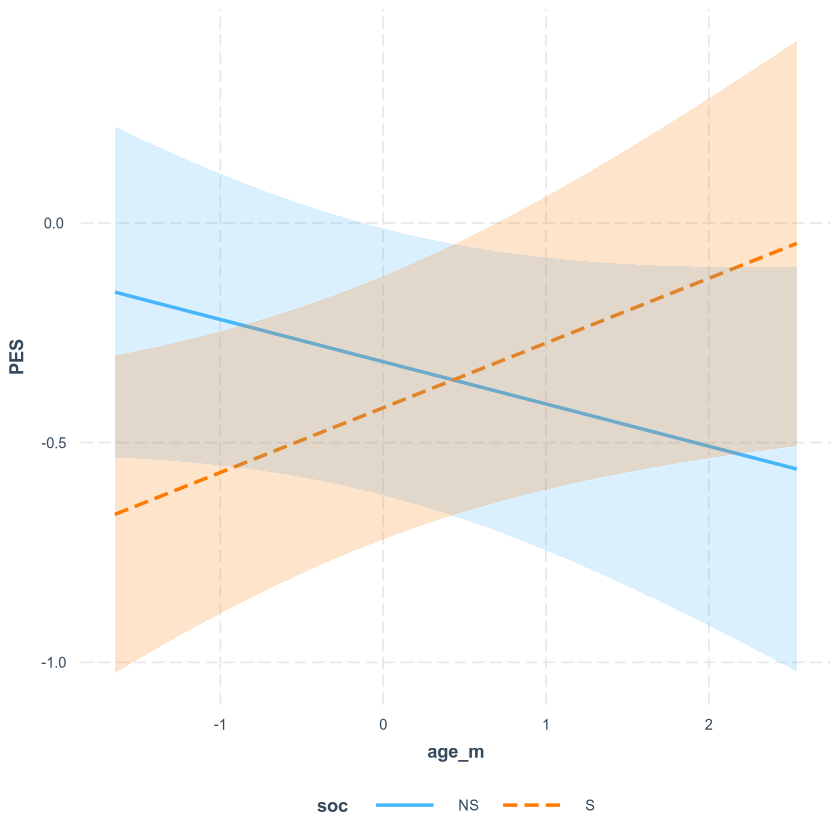

In [24]:
# test(emtrends(model, pairwise ~ age_m | soc, var="age_m"), adjust="fdr")

# png(file=sprintf("%s/%s.png", pic_path, "perceptual strength"), width=4, height=3, units="in", res=600)
interact_plot(model, pred = "age_m", modx="soc", interval = 1, dodge.width = 0.2, y.label = plot_y) + theme(legend.position = "bottom")

# ERN predicted by acc * soc * age

## Load data

In [2]:
rm(list = ls())
session = "s1_r1"
analysis_path = "/home/data/NDClab/analyses/thrive-theta-ddm/"
source(sprintf("%s/code/statistics/lmer_export_apa.R", analysis_path))
source(sprintf("%s/code/statistics/find_newest_file.R", analysis_path))
pic_path <- "/Users/fzaki001/thrive-theta-ddm/results/figures/ms"
# tf_data <- read.csv("/Users/fzaki001/IDENTIFIABLE/tf_data_collapsed_merged.csv")
tf_data <- read.csv(find_newest_file(sprintf("%s/derivatives/csv/%s/thrive*long*.csv", analysis_path, session)))
table_output_path = sprintf("%s/derivatives/statistics/full_sample/", analysis_path)

id_cols <- c('sub', 'age_m', 'sex', 'acc', 'soc', 'dp_inperson', 'first_soc')
data_cols <- c(
    'ERN',
    'ERN_laplacian',
    'bfne_b_scrdTotal_s1_r1_e1'
)
tf_data <- tf_data[, c(id_cols, data_cols)]
tf_data <- tf_data %>%
  filter(!if_all(c(data_cols), is.na))

tf_data$soc <- as.factor(tf_data$soc)
tf_data$sub <- as.factor(tf_data$sub)
tf_data$sex <- as.factor(tf_data$sex)
tf_data$acc <- as.factor(tf_data$acc)
tf_data$first_soc <- as.factor(tf_data$first_soc)
# tf_data$task_num <- as.factor(tf_data$task_num)
tf_data$dp_inperson <- as.factor(tf_data$dp_inperson)

tf_data[c("age_m", data_cols)] <- as.data.frame(scale(tf_data[c("age_m", data_cols)]))

tf_data$soc <- revalue(tf_data$soc, c("0" = "NS", "1" = "S"))
tf_data$sex <- revalue(tf_data$sex, c("1" = "M", "2" = "F"))
tf_data$acc <- revalue(tf_data$acc, c("0" = "Error", "1" = "Correct"))

contrasts(tf_data$soc) <- rev(contr.sum(2))
contrasts(tf_data$acc) <- rev(contr.sum(2))
contrasts(tf_data$first_soc) <- rev(contr.sum(2))
contrasts(tf_data$sex) <- rev(contr.sum(2))
# contrasts(tf_data$task_num) <- rev(contr.sum(2))
contrasts(tf_data$dp_inperson) <- rev(contr.sum(2))

[1] "The newest file is: /home/data/NDClab/analyses/thrive-theta-ddm//derivatives/csv/s1_r1/thrive_long_s1_r1_28_01_2026_19_47_25.csv"


Warning message:
"There was 1 warning in `filter()`.
i In argument: `!if_all(c(data_cols), is.na)`.
Caused by warning:
! Using an external vector in selections was deprecated in tidyselect 1.1.0.
i Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(data_cols)

  # Now:
  data %>% select(all_of(data_cols))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>."


In [6]:
label <- "ERN_bfne"
model <- lmer(ERN ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
ERN ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson +  
    (1 | sub)
   Data: tf_data

REML criterion at convergence: 1907.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1201 -0.5645  0.0028  0.5779  3.4271 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.3994   0.6320  
 Residual             0.3190   0.5648  
Number of obs: 847, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                               -1.712e-02  6.689e-02  2.238e+02
acc1                                       4.830e-01  1.949e-02  6.091e+02
age_m                                     -1.638e-01  4.598e-02  2.241e+02
soc1                                      -1.442e-04  1.997e-02  6.302e+02
bfne_b_scrdTotal_s1_r1_e1                 -2.742e-02  4.808e-02  2.245e+02
sex1           

Computing profile confidence intervals ...



In [7]:
label <- "ERN_laplacian_bfne"
model <- lmer(ERN_laplacian ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 + sex + dp_inperson + (1 | sub),
              data = tf_data)
summary(model)
lmer_export_apa(model = model, path = sprintf("%s/%s.docx", table_output_path, label))


Correlation matrix not shown by default, as p = 18 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: ERN_laplacian ~ acc * age_m * soc * bfne_b_scrdTotal_s1_r1_e1 +  
    sex + dp_inperson + (1 | sub)
   Data: tf_data

REML criterion at convergence: 1842.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8670 -0.5384  0.0132  0.5482  2.8516 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept) 0.5339   0.7307  
 Residual             0.2692   0.5188  
Number of obs: 841, groups:  sub, 230

Fixed effects:
                                            Estimate Std. Error         df
(Intercept)                                -0.045491   0.074696 221.721082
acc1                                        0.416219   0.018018 601.013348
age_m                                      -0.011306   0.051358 222.425284
soc1                                       -0.023554   0.018494 615.851391
bfne_b_scrdTotal_s1_r1_e1                  -0.005473   0.053658 222.079289
sex1  

Computing profile confidence intervals ...

